<div dir="rtl">

# سؤال ۹: خانه‌های دارای امکانات در کدام مناطق‌اند

می‌خوایم ببینیم خونه هایی که بالکن و آسانسور و نگهبان و باربیکیو و استخر دارن بیشتر در کدوم مناطق هستند.
داده از خروجی پایپ‌لاین اصلی خونده میشه

</div>

<div dir="rtl">

## ۱. هر امکان در کدام دسته پرسیده شده

فرم دیوار برای هر دسته سؤال‌های متفاوتی داره. مثلا آسانسور فقط برای آپارتمان و دفتر پرسیده شده و بالکن برای آپارتمان و خانه و ویلا. نگهبان و باربیکیو و استخر هم فقط برای خانه و ویلا.
پس هر امکان رو فقط داخل دسته‌هایی بررسی می‌کنیم که واقعا پرسیده شده. دفتر را هم کنار گذاشتم چون سؤال درباره خانه‌هاست.

</div>

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_parquet("../data/Divar_cleaned.parquet")

amenities = ["has_balcony", "has_elevator", "has_security_guard", "has_barbecue", "has_pool"]
answered = df[amenities].notna().groupby(df["cat3_slug"]).sum()
answered = answered[answered.sum(axis=1) > 0]
answered

,has_balcony,has_elevator,has_security_guard,has_barbecue,has_pool
cat3_slug,,,,,
apartment-rent,125302,211867,0,0,0
apartment-sell,194485,303378,1,1,1
house-villa-rent,64663,0,5021,5107,4991
house-villa-sell,121736,0,22211,21841,20234
industry-agriculture-business-sell,0,1,0,0,0
office-rent,0,21347,0,0,0
office-sell,0,5155,0,0,0
plot-old,1,0,0,0,0
villa,0,0,4079,4249,4164


<div dir="rtl">

## ۲. درصد هر امکان در هر شهر

تعداد خام به درد نمی‌خورع  چون اونموقع تهران در همه امکانات اول میشه فقط چون آگهی بیشتری داره. برای همین در هر شهر درصد آگهی‌هایی که اون امکان رو دارن  حساب کردم. فقط آگهی‌هایی حساب شدن که به آن سؤال جواب داده‌بودن.
شهرهایی که کمتر از ۱۰۰ آگهی جواب‌داده داشتن کنار گذاشته شدن. وگرنه به طور مثال شهری با ۲ آگهی و ۲ استخر رو ۱۰۰ درصد نشان میداد.

</div>

In [9]:
apartment_cats = ["apartment-sell", "apartment-rent"]
villa_cats = ["house-villa-sell", "house-villa-rent", "villa"]
residential_cats = apartment_cats + ["house-villa-sell", "house-villa-rent"]
plan = {
    "has_elevator": apartment_cats,
    "has_balcony": residential_cats,
    "has_security_guard": villa_cats,
    "has_barbecue": villa_cats,
    "has_pool": villa_cats,
}

def amenity_by_city(data, col, min_ads=100):
    answered = data[data[col].notna()]
    table = answered.groupby("city_slug")[col].agg(ads="size", share="mean")
    table = table[table["ads"] >= min_ads]
    table["share"] = (table["share"] * 100).round(1)
    return table.sort_values("share", ascending=False)

results = {}
for col, cats in plan.items():
    group = df[df["cat3_slug"].isin(cats)]
    results[col] = amenity_by_city(group, col)
    overall = group[col].mean() * 100
    print(f"{col}: miangin kol {overall:.1f}% | shahr ha: {len(results[col])}")
    display(results[col].head(10))

has_elevator: miangin kol 67.7% | shahr ha: 182


,ads,share
city_slug,,
garmdareh,1295,95.9
sorkhrood,655,94.7
pardis-city,9796,93.2
sarein,168,90.5
sadra,2935,88.7
urmia,4354,88.5
izadshahr,202,86.1
babolsar,1038,85.6
parand-city,8449,85.3


has_balcony: miangin kol 81.5% | shahr ha: 254


,ads,share
city_slug,,
pardis-city,6896,99.1
garmdareh,952,98.5
parand-city,4653,98.3
shirgah,129,97.7
kelarabad,201,97.5
andisheh-new-town,14010,96.7
emamzadeh-abdollah,151,96.7
izadshahr,944,96.2
nashtarud,233,96.1


has_security_guard: miangin kol 21.3% | shahr ha: 62


,ads,share
city_slug,,
chamestan,3320,50.9
nur,2423,47.0
royan,297,42.1
emamzadeh-abdollah,106,40.6
mahmudabad,1650,39.6
izadshahr,396,37.1
abbasabad-mazandaran,168,34.5
kelarabad,105,34.3
amol,915,33.7


has_barbecue: miangin kol 25.1% | shahr ha: 62


,ads,share
city_slug,,
salman-shahr,375,50.9
sorkhrood,723,49.2
ramsar,839,44.8
kelarabad,104,44.2
chaf-chamkhale,162,43.2
royan,290,43.1
chamestan,2994,41.8
mahmudabad,1650,40.5
kelarestan,295,40.0


has_pool: miangin kol 12.7% | shahr ha: 60


,ads,share
city_slug,,
salman-shahr,349,34.1
ramsar,808,32.1
sorkhrood,649,31.9
nur,2064,26.0
royan,259,25.5
mahmudabad,1443,24.6
izadshahr,346,22.8
babolsar,425,21.4
chamestan,2639,21.2


<div dir="rtl">

## ۳. ده شهر اول برای هر امکان

خط قرمز میانگین کل ایرانه. هر چه میله از خط دورتر میشه آن امکان توی اون شهر رایج‌ تر از بقیه ایرانه

</div>

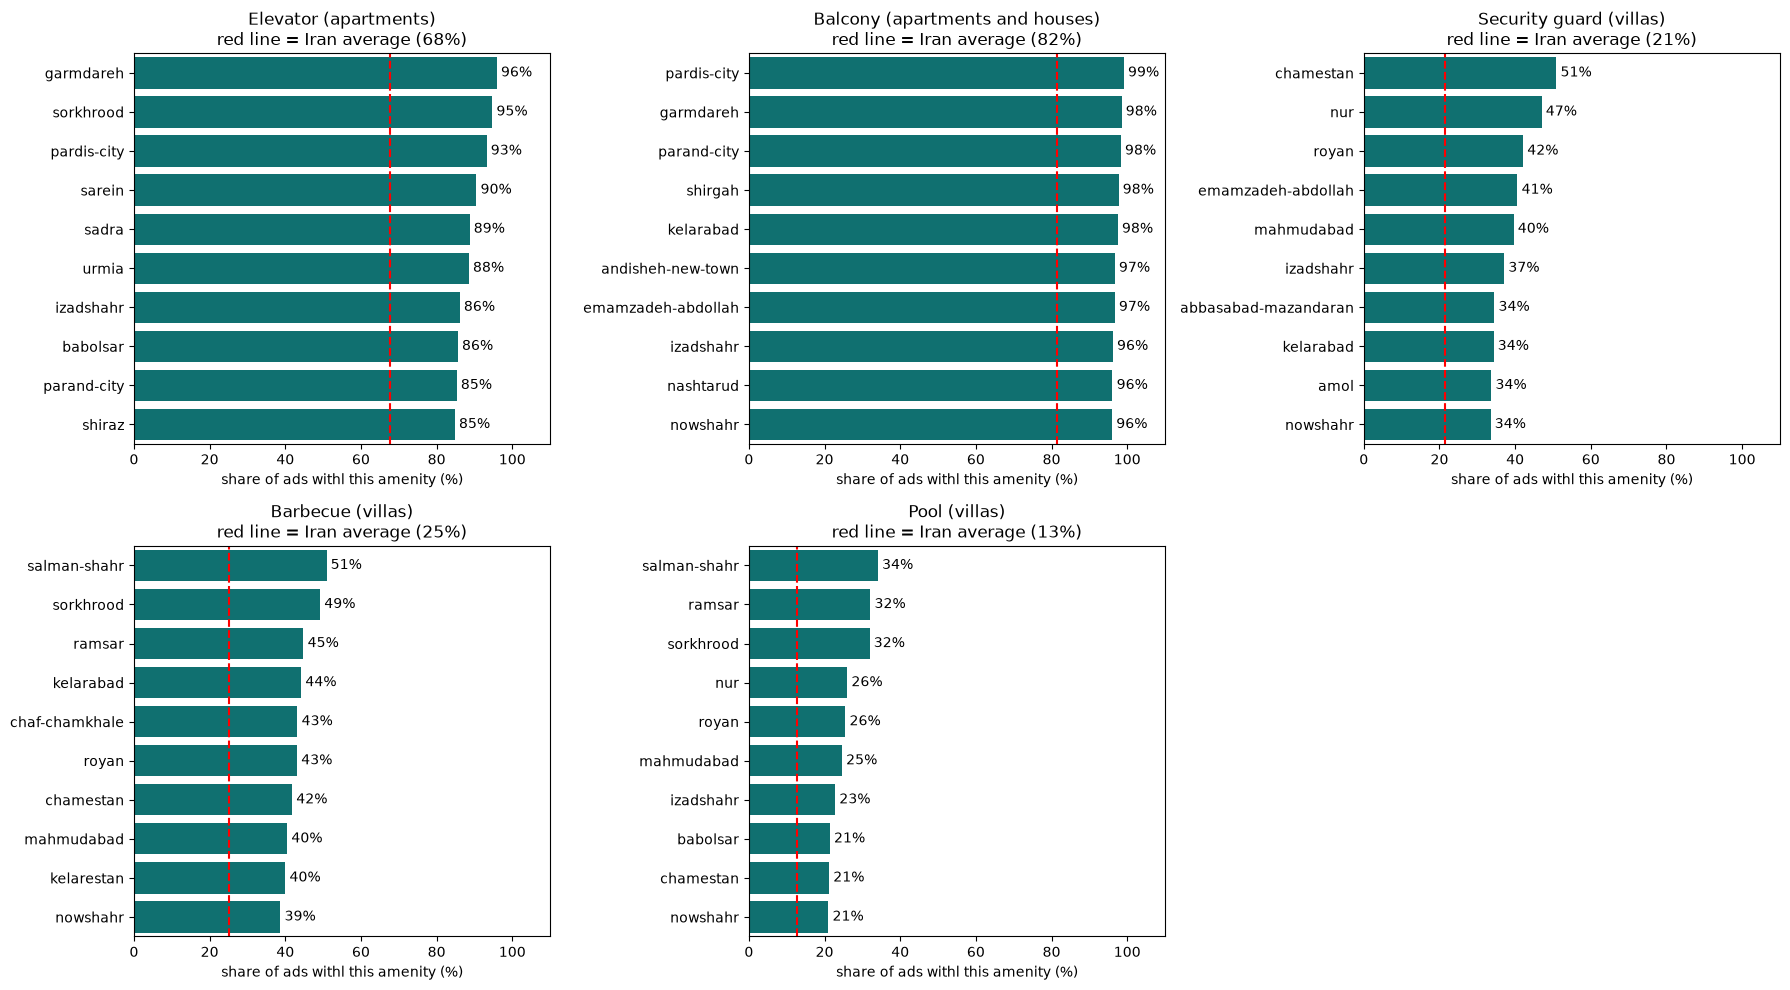

In [10]:
titles = {
    "has_elevator": "Elevator (apartments)",
    "has_balcony": "Balcony (apartments and houses)",
    "has_security_guard": "Security guard (villas)",
    "has_barbecue": "Barbecue (villas)",
    "has_pool": "Pool (villas)",
}
ig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (col, cats) in zip(axes, plan.items()):
    top = results[col].head(10)
    overall = df[df["cat3_slug"].isin(cats)][col].mean() * 100

    sns.barplot(x=top["share"], y=top.index, ax=ax, color="teal")
    ax.bar_label(ax.containers[0], fmt="%.0f%%", padding=3)
    ax.axvline(overall, color="red", linestyle="--")
    ax.set_title(f"{titles[col]}\nred line = Iran average ({overall:.0f}%)")
    ax.set_xlabel("share of ads withl this amenity (%)")
    ax.set_ylabel("")
    ax.set_xlim(0, 110)
axes[-1].axis("off")
plt.tight_layout()
plt.show()

<div dir="rtl">

## ۴. این شهرها روی نقشه کجا هستند

هر دایره یک شهر. رنگ دایره درصداون امکانات رو نشون مید. نقشه دوم فقط شمال را نشان میده چون ویلا ها اونجان به طورر تقریبی

</div>

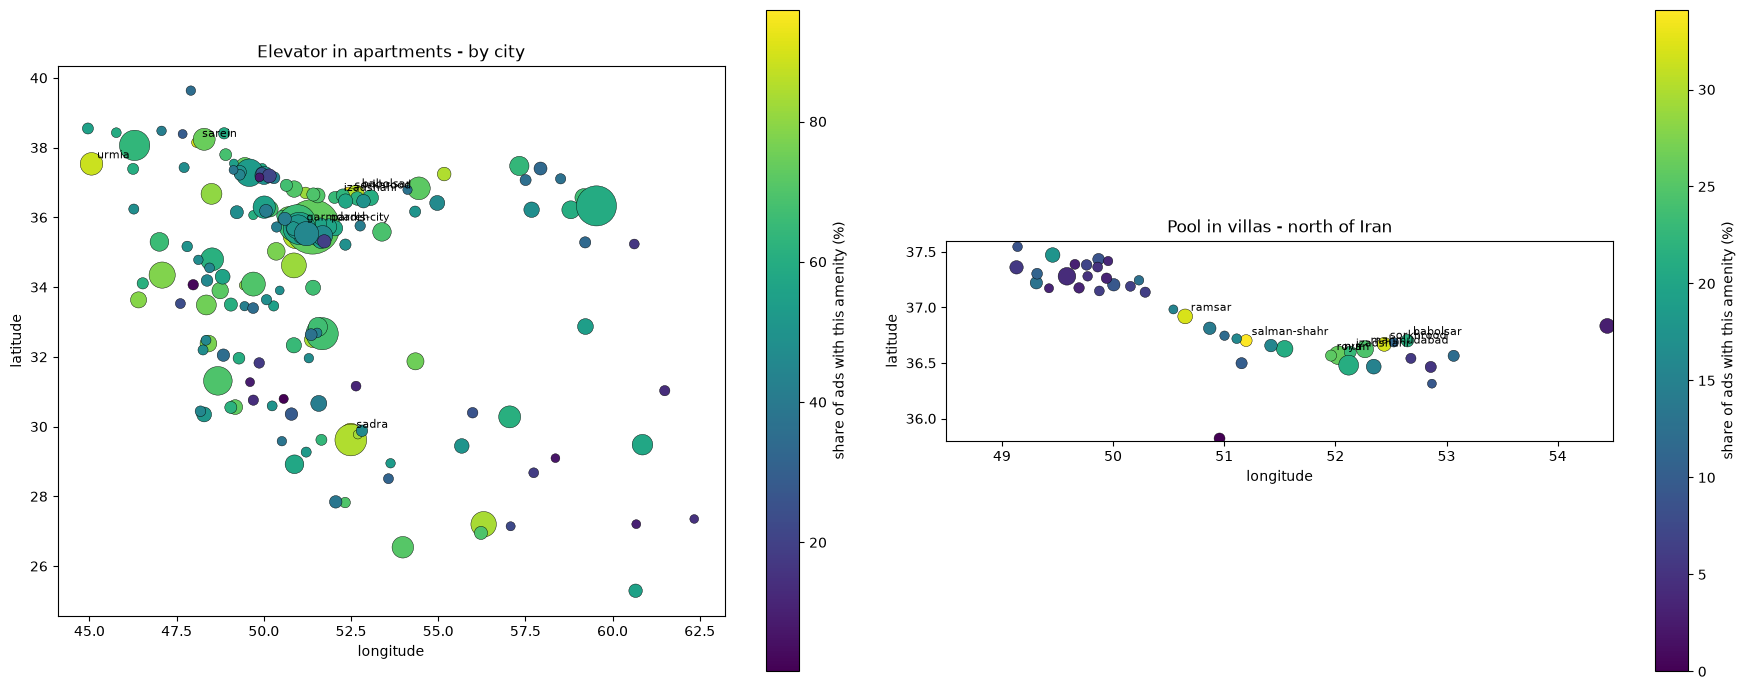

In [11]:
lat, lon = "location_latitude", "location_longitude"
centers = df[df["coord_status"] == "ok"].groupby("city_slug")[[lat, lon]].median()
maps = [
    ("has_elevator", "Elevator in apartments - by city", None),
    ("has_pool", "Pool in villas - north of Iran", (35.8, 37.6, 48.5, 54.5)),
]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, (col, title, box) in zip(axes, maps):
    table = results[col].join(centers, how="inner")

    points = ax.scatter(table[lon], table[lat], s=np.sqrt(table["ads"]) * 4,
                        c=table["share"], cmap="viridis", edgecolor="black", linewidth=0.3)
    fig.colorbar(points, ax=ax, label="share of ads with this amenity (%)")

    for name, row in table.nlargest(8, "share").iterrows():
        ax.annotate(name, (row[lon], row[lat]), fontsize=8,
                    xytext=(4, 4), textcoords="offset points")
    if box:
        ax.set_ylim(box[0], box[1])
        ax.set_xlim(box[2], box[3])

    ax.set_title(title)
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()